# Exploratory Data Analysis

#### Understanding the data through visualizations before building any model.
Working with the cleaned dataset from notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/diabetes_cleaned.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Feature Distributions by Outcome

##### Comparing how each feature looks for diabetic vs non-diabetic patients.
This helps understand which features are most useful for prediction.

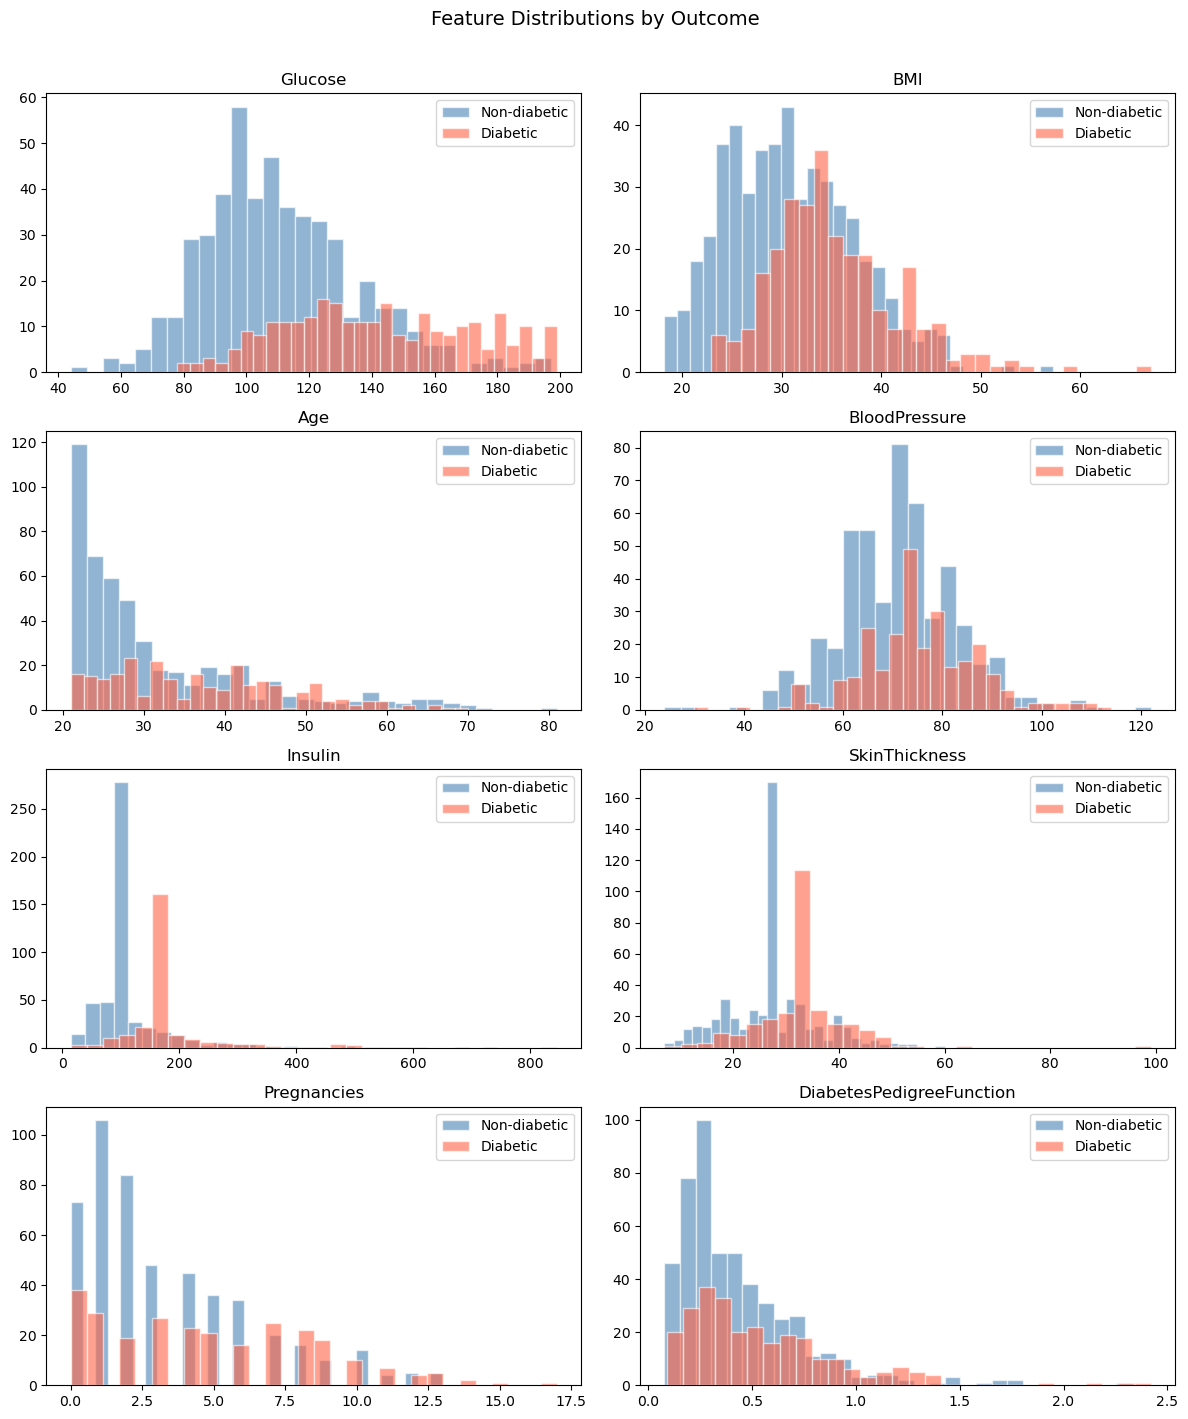

In [2]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 
            'Insulin', 'SkinThickness', 'Pregnancies', 
            'DiabetesPedigreeFunction']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    diabetic     = df[df['Outcome'] == 1][col]
    non_diabetic = df[df['Outcome'] == 0][col]
    
    axes[i].hist(non_diabetic, bins=30, alpha=0.6, 
                 color='steelblue', label='Non-diabetic', edgecolor='white')
    axes[i].hist(diabetic, bins=30, alpha=0.6, 
                 color='tomato', label='Diabetic', edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Average Feature Values by Outcome

##### A simple comparison of mean values between the two groups.
Larger differences suggest stronger predictive power.

In [3]:
group_means = df.groupby('Outcome')[features].mean().round(2)
group_means.index = ['Non-diabetic', 'Diabetic']
print(group_means.T)

                          Non-diabetic  Diabetic
Glucose                         110.62    142.30
BMI                              30.85     35.40
Age                              31.19     37.07
BloodPressure                    70.84     75.27
Insulin                         117.17    187.62
SkinThickness                    27.17     32.67
Pregnancies                       3.30      4.87
DiabetesPedigreeFunction          0.43      0.55


## Correlation Heatmap
Checking how features relate to each other and to the target variable.

High correlation between two features means they carry similar information.

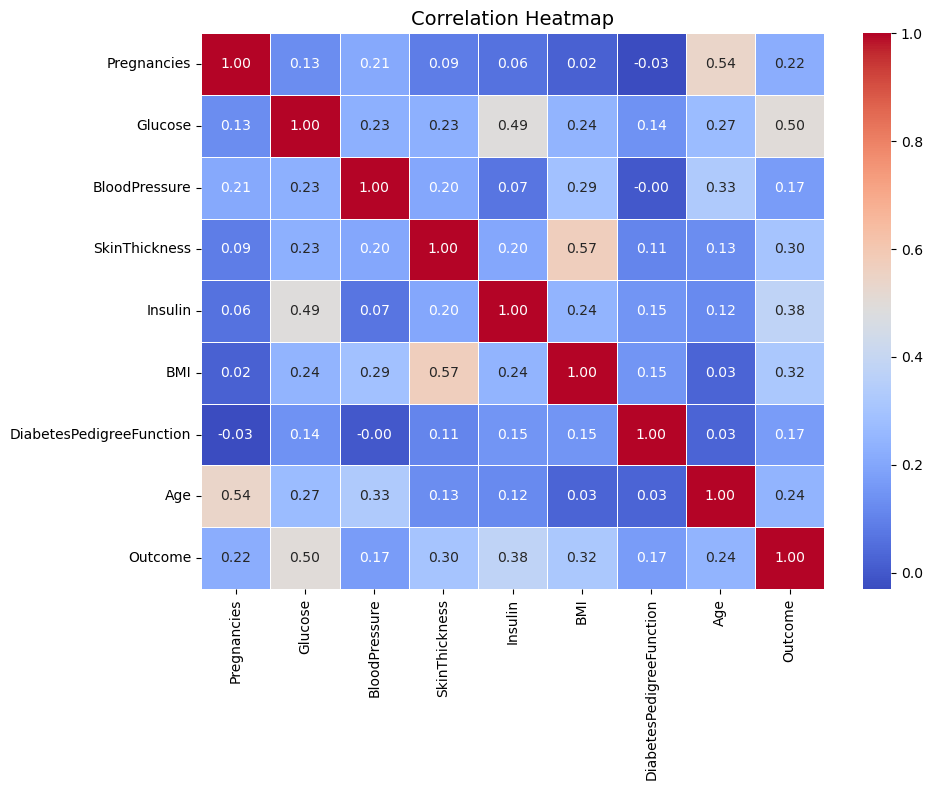

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr().round(2),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Boxplots — Spotting Outliers

Boxplots show the spread of each feature and any extreme values.

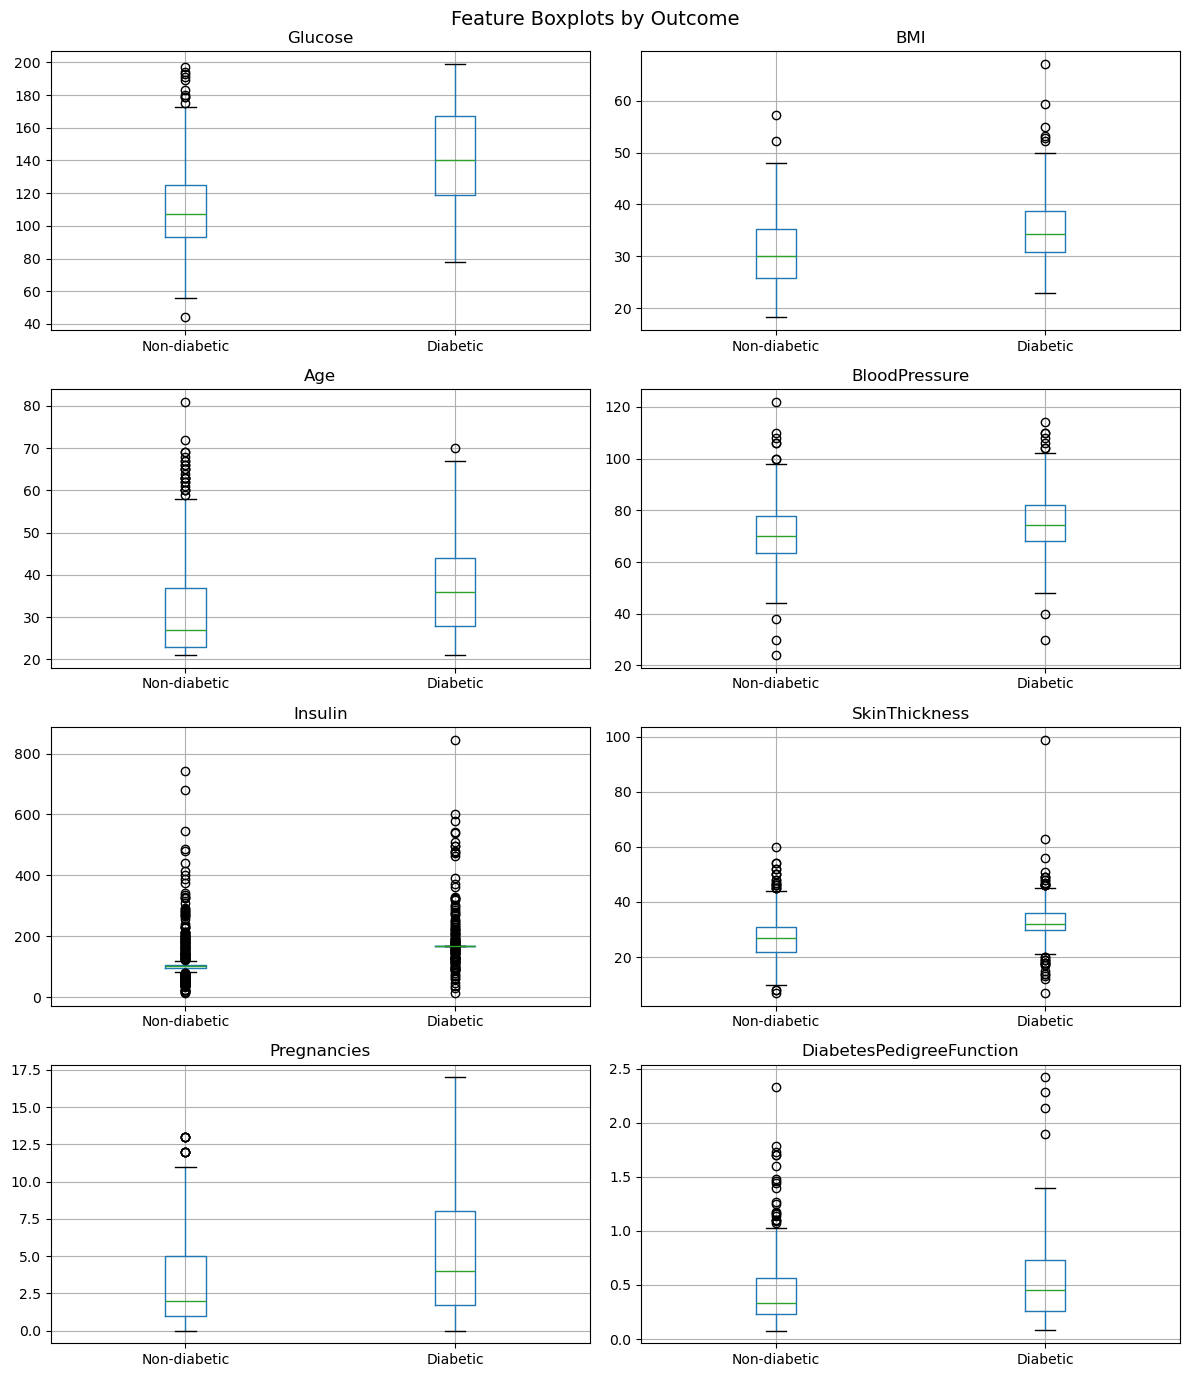

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='Outcome', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Non-diabetic', 'Diabetic'])

plt.suptitle('Feature Boxplots by Outcome', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Observations

Looking at the charts above, these features show the clearest 
separation between diabetic and non-diabetic patients:

- **Glucose** — diabetic patients have noticeably higher glucose levels
- **BMI** — higher BMI is associated with diabetes
- **Age** — diabetic patients tend to be older
- **DiabetesPedigreeFunction** — higher genetic risk in diabetic group

Insulin and SkinThickness show more overlap between groups,
meaning they may be weaker predictors on their own.